In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
jax.config.update('jax_default_device', 'cpu')
jax.config.update('jax_default_matmul_precision', 'highest')

In [2]:
import jax.numpy as jnp
import jax.random as jr
import jax.tree_util as jtu
import equinox as eqx
import matplotlib.pyplot as plt
import seaborn as sns

from functools import partial
from jax import vmap
from scipy.linalg import orthogonal_procrustes

from sppcax.distributions import MultivariateNormalInverseGamma as MVNIG

from sppcax.models import BayesianFactorAnalysis as BFA
from sppcax.models.dynamic_factor_analysis import (
    ParamsLGSSM, ParamsLGSSMInitial, ParamsLGSSMDynamics,
    ParamsLGSSMEmissions,
)
from sppcax.inference.utils import ParamsLGSSMVB

# Testing PXL-EM for Bayesian Factor Analysis

This notebook tests the **Parameter-Expanded Likelihood EM (PXL-EM)** algorithm
from Rocková & George (2016) applied to Bayesian Factor Analysis.

The key idea: after a standard M-step produces $\mathbf{B}^*$ (loading matrix in
the expanded parameter space), we apply a rotation correction:

$$\mathbf{A} = \frac{1}{N} \sum_{i=1}^N \mathbb{E}[\mathbf{z}_i \mathbf{z}_i^\top], \quad
\mathbf{A}_L = \text{chol}(\mathbf{A}), \quad
\mathbf{H}_{\text{new}} = \mathbf{B}^* \mathbf{A}_L$$

This correction accelerates convergence by reducing the coupling between
the loading matrix and latent factors.

## 1. Generate Synthetic FA Data

Y shape: (500, 20), H_true shape: (20, 5)
H_true sparsity: 76.0% zeros


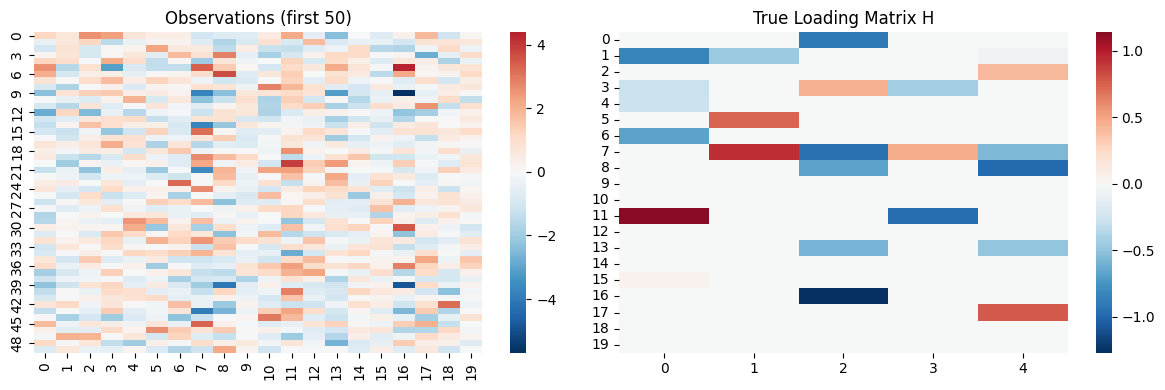

In [3]:
# Data dimensions
N = 500   # observations
D = 20    # features
K = 5     # latent components

key = jr.PRNGKey(42)

# True sparse loading matrix
key, k1, k2 = jr.split(key, 3)
H_true = jr.normal(k1, (D, K)) * jr.bernoulli(k2, p=0.3, shape=(D, K))

# True diagonal noise covariance
key, k1 = jr.split(key)
R_true_diag = jr.uniform(k1, (D,), minval=0.3, maxval=1.0)

# Generate data: z ~ N(0, I), x = H z + noise
key, k1, k2 = jr.split(key, 3)
Z_true = jr.normal(k1, (N, K))
noise = jr.normal(k2, (N, D)) * jnp.sqrt(R_true_diag)
Y = Z_true @ H_true.T + noise

print(f"Y shape: {Y.shape}, H_true shape: {H_true.shape}")
print(f"H_true sparsity: {jnp.isclose(H_true, 0.).mean():.1%} zeros")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(Y[:50], ax=axes[0], cmap='RdBu_r', center=0)
axes[0].set_title('Observations (first 50)')
sns.heatmap(H_true, ax=axes[1], cmap='RdBu_r', center=0, annot=False)
axes[1].set_title('True Loading Matrix H')
plt.tight_layout()

## 2. PXL-EM Correction Function

In [4]:
def pxl_em_correction(params, sum_zzT, state_dim, N):
    """Apply PXL-EM rotation correction after M-step.
    
    After the standard M-step produces B* (loading in expanded space),
    compute the optimal contraction: H_new = B* @ chol(A)
    where A = (1/N) * sum E[z z^T] (top-left K×K block).
    """
    # Extract second moment of latent factors (K×K block)
    A = sum_zzT[:state_dim, :state_dim] / N
    A_L = jnp.linalg.cholesky(A)

    # Rotate loading matrix: H_new = B* @ A_L
    H = params.emissions.weights
    H_new = H @ A_L

    # Update params
    params = params._replace(
        emissions=params.emissions._replace(weights=H_new)
    )
    return params, A_L

## 3. EM Loop Functions

In [5]:
def fit_pxl_em(model, params, props, Y, key, num_iters=200):
    """PXL-EM: standard EM + rotation correction after each M-step."""
    batch_emissions = Y[:, None, :]  # (N, 1, D) for static FA
    batch_inputs = jnp.zeros((Y.shape[0], 1, 0))
    N = Y.shape[0]

    m_step_state = model.initialize_m_step_state(params, props)
    kl_div = 0.0
    elbos = []

    for i in range(num_iters):
        key, _key = jr.split(key)
        # E-step
        batch_stats, lls = vmap(partial(model.e_step, params))(batch_emissions, batch_inputs)
        elbo = lls.sum() - kl_div
        elbos.append(float(elbo))

        # M-step (gives B* in PXL-EM notation)
        params, kl_div, m_step_state = model.m_step(params, props, batch_stats, m_step_state, key=_key)

        # PXL-EM correction
        stats = jtu.tree_map(partial(jnp.sum, axis=0), batch_stats)
        _, _, emission_stats = stats
        sum_zzT = emission_stats[0]  # (K+bias, K+bias)
        params, A_L = pxl_em_correction(params, sum_zzT, model.state_dim, N)

    model.ard_prior = m_step_state
    return params, jnp.array(elbos)

## 4. VBEM Loop Functions

In [6]:
def fit_pxl_vbem(model, params, props, Y, key, num_iters=200):
    """PXL-VBEM: VBEM + rotation correction after each VB M-step.
    
    The correction rotates H and transforms the VB correction term C_em:
        H_new = H @ A_L
        C_em_new = A_L^T @ C_em @ A_L  (since C_em = sum_d E[Sigma_d] * Cov(h_d))
    """
    batch_emissions = Y[:, None, :]  # (N, 1, D) for static FA
    batch_inputs = jnp.zeros((Y.shape[0], 1, 0))
    N = Y.shape[0]

    m_step_state = model.initialize_m_step_state(params, props)
    kl_div = 0.0
    elbos = []

    for i in range(num_iters):
        key, _key = jr.split(key)
        # VB E-step
        batch_stats, lls = vmap(partial(model.vbe_step, params))(batch_emissions, batch_inputs)
        elbo = lls.sum() - kl_div
        elbos.append(float(elbo))

        # VB M-step (gives B* in PXL-EM notation)
        params, kl_div, m_step_state = model.vbm_step(params, props, batch_stats, m_step_state, key=_key)

        # PXL-EM correction
        stats = jtu.tree_map(partial(jnp.sum, axis=0), batch_stats)
        _, _, emission_stats = stats
        sum_zzT = emission_stats[0]  # (K+bias, K+bias)
        A = sum_zzT[:model.state_dim, :model.state_dim] / N
        A_L = jnp.linalg.cholesky(A)

        # Rotate loading matrix
        H = params.emissions.weights
        H_new = H @ A_L

        # Transform VB correction: C_em_new = A_L^T @ C_em @ A_L
        C_em = params.emissions.correction
        K_dim = model.state_dim
        # C_em has shape (K+bias, K+bias), transform only the K×K block
        A_L_full = jnp.eye(C_em.shape[0])
        A_L_full = A_L_full.at[:K_dim, :K_dim].set(A_L)
        C_em_new = A_L_full.T @ C_em @ A_L_full

        params = params._replace(
            emissions=params.emissions._replace(weights=H_new, correction=C_em_new)
        )

    model.ard_prior = m_step_state
    return params, jnp.array(elbos)

## 5. Experiments Without BMR

In [7]:
NUM_ITERS = 40

emission_prior = MVNIG(
    loc=jnp.zeros((D, 2 * K + 1)),
    isotropic_noise=False
)

# --- Standard EM ---
model = BFA(2 * K, D, emission_prior=emission_prior, has_ard=False, use_bmr=False)
key, k1, k2 = jr.split(key, 3)
params_init, props = model.initialize(k1)
params_em, elbos_em = model.fit_em(params_init, props, Y, k2, num_iters=NUM_ITERS)
print(f"EM final ELBO: {elbos_em[-1]:.1f}")

# --- PXL-EM ---
key, k1, k2 = jr.split(key, 3)
params_pxl, elbos_pxl = fit_pxl_em(model, params_init, props, Y, k2, num_iters=NUM_ITERS)
print(f"PXL-EM final ELBO: {elbos_pxl[-1]:.1f}")

# --- Standard VBEM ---
key, k1, k2 = jr.split(key, 3)
params_vbem_init, props_vbem = model.initialize(k1, variational_bayes=True)
params_vbem, elbos_vbem = model.fit_vbem(params_vbem_init, props_vbem, Y, k2, num_iters=NUM_ITERS)
print(f"VBEM final ELBO: {elbos_vbem[-1]:.1f}")

# --- PXL-VBEM ---
key, k1, k2 = jr.split(key, 3)
params_pxl_vb, elbos_pxl_vb = fit_pxl_vbem(model, params_vbem_init, props_vbem, Y, k2, num_iters=NUM_ITERS)
print(f"PXL-VBEM final ELBO: {elbos_pxl_vb[-1]:.1f}")

EM final ELBO: -14938.9
PXL-EM final ELBO: -14926.8
VBEM final ELBO: -15587.2
PXL-VBEM final ELBO: -15581.7


### Convergence Comparison (No BMR)

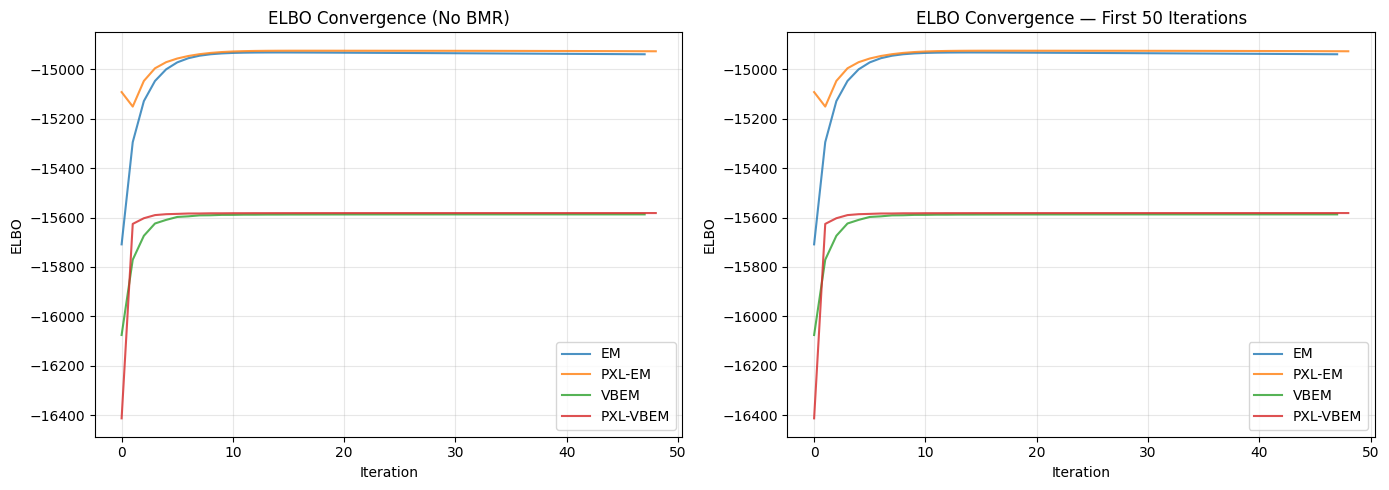

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ELBO convergence
ax = axes[0]
ax.plot(elbos_em[1:], label='EM', alpha=0.8)
ax.plot(elbos_pxl[1:], label='PXL-EM', alpha=0.8)
ax.plot(elbos_vbem[1:], label='VBEM', alpha=0.8)
ax.plot(elbos_pxl_vb[1:], label='PXL-VBEM', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence (No BMR)')
ax.legend()
ax.grid(True, alpha=0.3)

# Zoomed view of first 50 iterations
ax = axes[1]
ax.plot(elbos_em[1:50], label='EM', alpha=0.8)
ax.plot(elbos_pxl[1:50], label='PXL-EM', alpha=0.8)
ax.plot(elbos_vbem[1:50], label='VBEM', alpha=0.8)
ax.plot(elbos_pxl_vb[1:50], label='PXL-VBEM', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence — First 50 Iterations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

### Loading Matrix Recovery (No BMR)

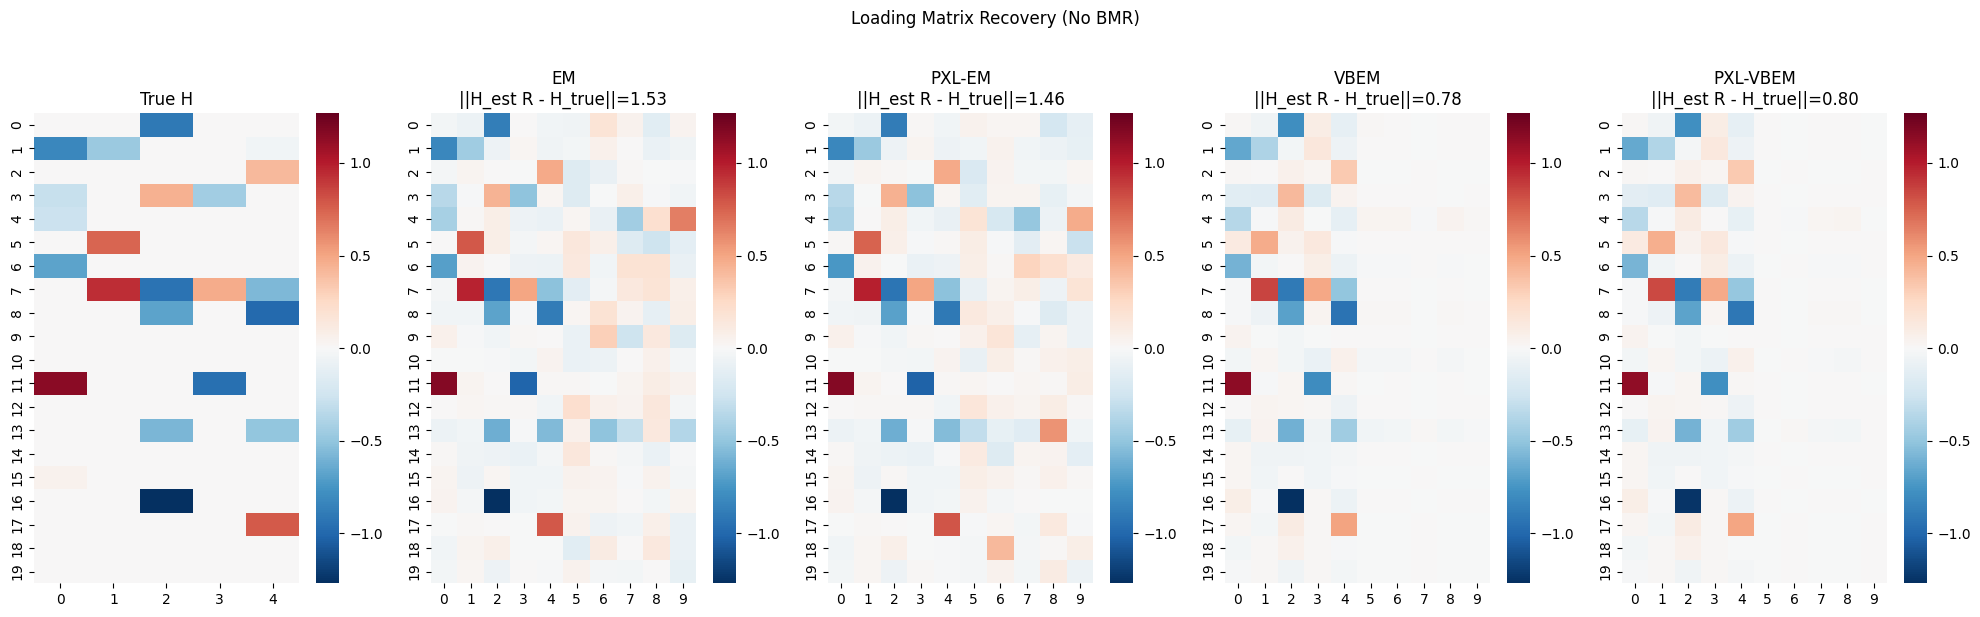

In [9]:
def procrustes_similarity(H_est, H_true):
    """Align H_est to H_true via orthogonal Procrustes.
    
    Handles different number of columns by zero-padding the smaller matrix.
    Returns aligned H_est and Frobenius disparity.
    """
    D, K_est = H_est.shape
    K_true = H_true.shape[1]
    K_max = max(K_est, K_true)
    
    # Pad to equal column count
    A = jnp.pad(H_est, [(0, 0), (0, K_max - K_est)]) if K_est < K_max else H_est
    B = jnp.pad(H_true, [(0, 0), (0, K_max - K_true)]) if K_true < K_max else H_true
    
    R, _ = orthogonal_procrustes(A, B)
    H_aligned = A @ R
    disparity = jnp.linalg.norm(H_aligned - B, 'fro')
    return H_aligned, float(disparity)


results_no_bmr = {
    'EM': params_em.emissions.weights,
    'PXL-EM': params_pxl.emissions.weights,
    'VBEM': params_vbem.emissions.weights,
    'PXL-VBEM': params_pxl_vb.emissions.weights,
}

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
vmax = jnp.abs(H_true).max()

sns.heatmap(H_true, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True H')

for idx, (name, H_est) in enumerate(results_no_bmr.items()):
    H_aligned, disparity = procrustes_similarity(H_est, H_true)
    sns.heatmap(H_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
    axes[idx + 1].set_title(f'{name}\n||H_est R - H_true||={disparity:.2f}')

plt.suptitle('Loading Matrix Recovery (No BMR)', y=1.02)
plt.tight_layout()

## 6. Experiments With BMR

In [ ]:
NUM_ITERS_BMR = 40

# --- Standard EM + BMR ---
model_bmr = BFA(2 * K, D, emission_prior=emission_prior, has_ard=False, use_bmr=True)
key, k1, k2 = jr.split(key, 3)
params_init_bmr, props_bmr = model_bmr.initialize(k1)
params_em_bmr, elbos_em_bmr = model_bmr.fit_em(params_init_bmr, props_bmr, Y, k2, num_iters=NUM_ITERS_BMR)
print(f"EM+BMR final ELBO: {elbos_em_bmr[-1]:.1f}")

# --- PXL-EM + BMR ---
model_bmr = BFA(2 * K, D, emission_prior=emission_prior, has_ard=False, use_bmr=True)
key, k1, k2 = jr.split(key, 3)
params_pxl_bmr, elbos_pxl_bmr = fit_pxl_em(model_bmr, params_init_bmr, props_bmr, Y, k2, num_iters=NUM_ITERS_BMR)
print(f"PXL-EM+BMR final ELBO: {elbos_pxl_bmr[-1]:.1f}")

EM+BMR final ELBO: -14362.1
PXL-EM+BMR final ELBO: -14110.9


In [16]:
# --- Standard EM + BMR ---
model_bmr = BFA(2 * K, D, emission_prior=emission_prior, has_ard=True, use_bmr=True)
params_em_bmr, elbos_em_bmr = model_bmr.fit_em(params_init_bmr, props_bmr, Y, k2, num_iters=NUM_ITERS_BMR)
print(f"EM+BMR final ELBO: {elbos_em_bmr[-1]:.1f}")

# --- PXL-EM + BMR ---
model_bmr = BFA(2 * K, D, emission_prior=emission_prior, has_ard=True, use_bmr=True)
params_pxl_bmr, elbos_pxl_bmr = fit_pxl_em(model_bmr, params_init_bmr, props_bmr, Y, k2, num_iters=NUM_ITERS_BMR)
print(f"PXL-EM+BMR final ELBO: {elbos_pxl_bmr[-1]:.1f}")

EM+BMR final ELBO: -14158.7
PXL-EM+BMR final ELBO: -14024.0


In [12]:
# --- Standard VBEM + BMR ---
key, k1, k2 = jr.split(key, 3)
params_vbem_bmr_init, props_vbem_bmr = model_bmr.initialize(k1, variational_bayes=True)
params_vbem_bmr, elbos_vbem_bmr = model_bmr.fit_vbem(params_vbem_bmr_init, props_vbem_bmr, Y, k2, num_iters=NUM_ITERS_BMR)
print(f"VBEM+BMR final ELBO: {elbos_vbem_bmr[-1]:.1f}")

# --- PXL-VBEM + BMR ---
key, k1, k2 = jr.split(key, 3)
params_pxl_vb_bmr, elbos_pxl_vb_bmr = fit_pxl_vbem(model_bmr, params_vbem_bmr_init, props_vbem_bmr, Y, k2, num_iters=NUM_ITERS_BMR)
print(f"PXL-VBEM+BMR final ELBO: {elbos_pxl_vb_bmr[-1]:.1f}")

VBEM+BMR final ELBO: -14995.6
PXL-VBEM+BMR final ELBO: -14984.8


In [18]:
# --- Standard VBEM + BMR ---
model_bmr = BFA(2 * K, D, emission_prior=emission_prior, has_ard=True, use_bmr=True)
key, k1, k2 = jr.split(key, 3)
params_vbem_bmr, elbos_vbem_bmr = model_bmr.fit_vbem(params_vbem_bmr_init, props_vbem_bmr, Y, k2, num_iters=NUM_ITERS_BMR)
print(f"VBEM+BMR final ELBO: {elbos_vbem_bmr[-1]:.1f}")

# --- PXL-VBEM + BMR ---
model_bmr = BFA(2 * K, D, emission_prior=emission_prior, has_ard=True, use_bmr=True)
params_pxl_vb_bmr, elbos_pxl_vb_bmr = fit_pxl_vbem(model_bmr, params_vbem_bmr_init, props_vbem_bmr, Y, k2, num_iters=NUM_ITERS_BMR)
print(f"PXL-VBEM+BMR final ELBO: {elbos_pxl_vb_bmr[-1]:.1f}")

VBEM+BMR final ELBO: -14909.2
PXL-VBEM+BMR final ELBO: -14893.4


### Convergence Comparison (With BMR)

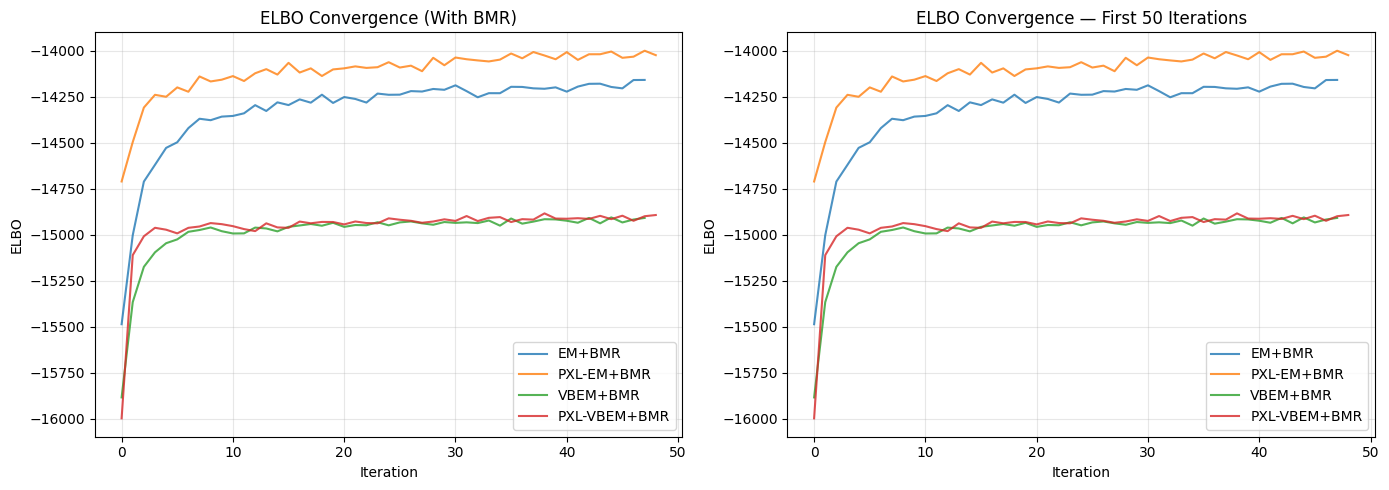

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(elbos_em_bmr[1:], label='EM+BMR', alpha=0.8)
ax.plot(elbos_pxl_bmr[1:], label='PXL-EM+BMR', alpha=0.8)
ax.plot(elbos_vbem_bmr[1:], label='VBEM+BMR', alpha=0.8)
ax.plot(elbos_pxl_vb_bmr[1:], label='PXL-VBEM+BMR', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence (With BMR)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(elbos_em_bmr[1:50], label='EM+BMR', alpha=0.8)
ax.plot(elbos_pxl_bmr[1:50], label='PXL-EM+BMR', alpha=0.8)
ax.plot(elbos_vbem_bmr[1:50], label='VBEM+BMR', alpha=0.8)
ax.plot(elbos_pxl_vb_bmr[1:50], label='PXL-VBEM+BMR', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence — First 50 Iterations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

### Loading Matrix Recovery (With BMR)

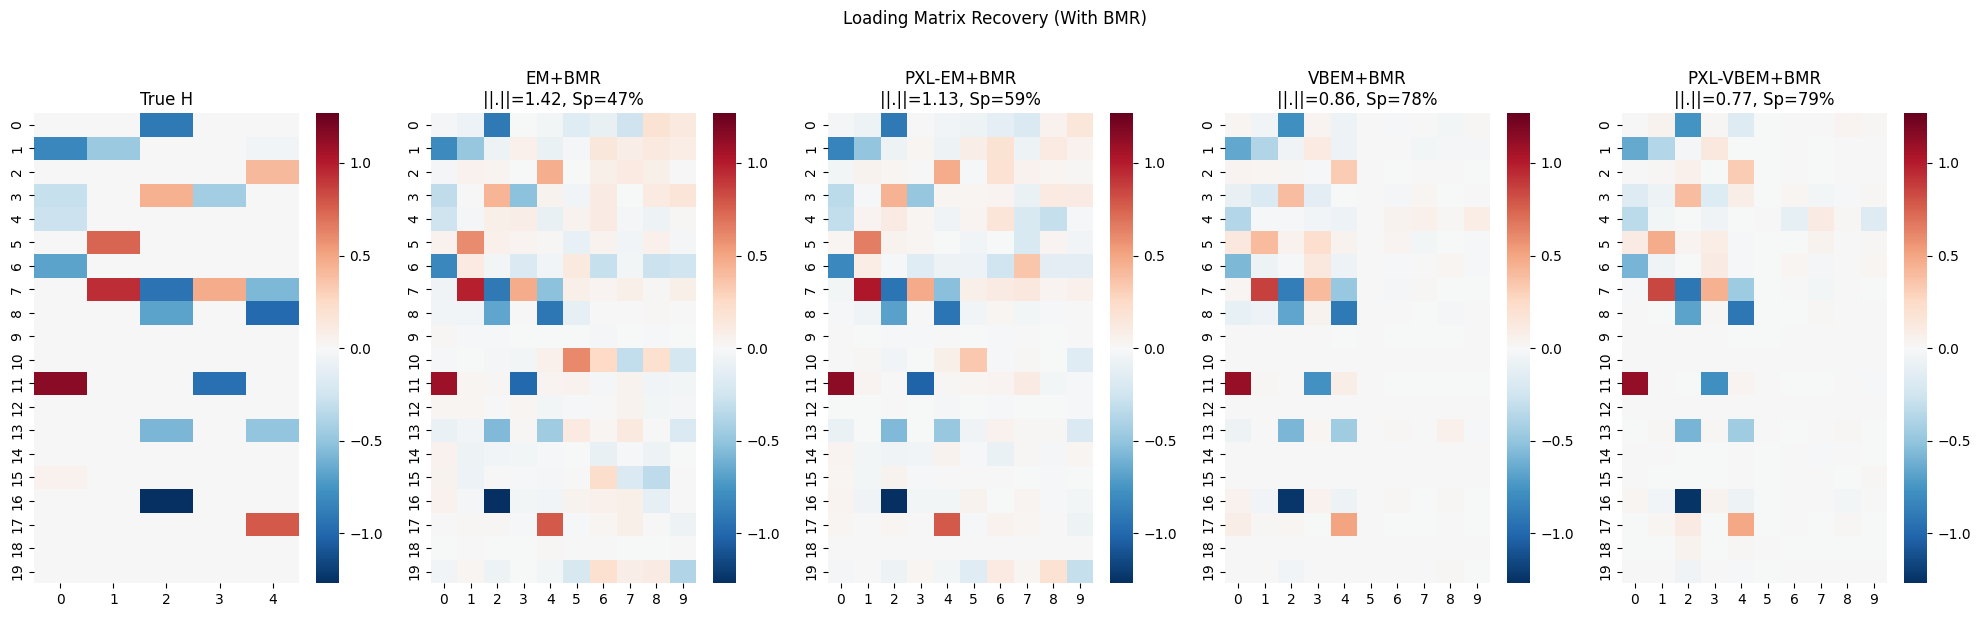

In [20]:
results_bmr = {
    'EM+BMR': params_em_bmr.emissions.weights,
    'PXL-EM+BMR': params_pxl_bmr.emissions.weights,
    'VBEM+BMR': params_vbem_bmr.emissions.weights,
    'PXL-VBEM+BMR': params_pxl_vb_bmr.emissions.weights,
}

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
vmax = jnp.abs(H_true).max()

sns.heatmap(H_true, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True H')

for idx, (name, H_est) in enumerate(results_bmr.items()):
    H_aligned, disparity = procrustes_similarity(H_est, H_true)
    sparsity = jnp.mean(jnp.abs(H_est) < 0.05)
    sns.heatmap(H_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
    axes[idx + 1].set_title(f'{name}\n||.||={disparity:.2f}, Sp={sparsity:.0%}')

plt.suptitle('Loading Matrix Recovery (With BMR)', y=1.02)
plt.tight_layout()

## 7. Summary

**Expected findings:**
- PXL-EM should converge faster than standard EM (fewer iterations to reach same ELBO)
- PXL-EM may find sparser solutions when combined with BMR
- The VB variants (VBEM, PXL-VBEM) provide uncertainty quantification through the correction terms

**PXL-EM correction:**
- After M-step: $\mathbf{H}_{\text{new}} = \mathbf{B}^* \cdot \text{chol}\left(\frac{1}{N}\sum_i \mathbb{E}[\mathbf{z}_i\mathbf{z}_i^\top]\right)$
- For VBEM, also transform: $\mathbf{C}_{\text{em,new}} = \mathbf{A}_L^\top \mathbf{C}_{\text{em}} \mathbf{A}_L$